1. Compute daily returns for all funds:
daily_return = nav_t / nav_t-1 - 1
Annualised return = (1 +
daily_return).prod()^(252/n) - 1

In [24]:
import pandas as pd

nav_his = pd.read_csv('../data/processed/nav_history.csv')
# print(nav_his.columns)

nav_his['date'] = pd.to_datetime(nav_his['date'])
nav_his.sort_values(['amfi_code', 'date'], inplace=True)

nav_his['daily_return'] = (
    nav_his.groupby('amfi_code')['nav']
    .pct_change()
)
return_df = nav_his.dropna(subset=['daily_return'])

annual_return_df = return_df.groupby('amfi_code')['daily_return'].apply(
    lambda x : (
        (1+x).prod()
    ) ** (252 / len(x)) - 1
).reset_index(name='anualized_return')
annual_return_df['anualized_return_percentage'] = (annual_return_df['anualized_return']*100).round(2)

annual_return_df.to_csv("../data/processed/returns_computed.csv", index=False)
# print(nav_his.info())
# print(annual_return_df.head(2))

2. Calculate CAGR for 1yr, 3yr, 5yr
periods: CAGR = (NAV_end /
NAV_start) ^ (1/n) - 1 for SBI
Bluechip, HDFC Top 100, etc.

In [7]:
import pandas as pd

nav_his = pd.read_csv('../data/processed/nav_history.csv')
# print(nav_his.columns)

nav_his['date'] = pd.to_datetime(nav_his['date'])
nav_his.sort_values(['amfi_code', 'date'], inplace=True)
print(nav_his.columns)
print(nav_his.iloc[-1])

Index(['amfi_code', 'date', 'nav'], dtype='object')
amfi_code                 149324
date         2026-05-29 00:00:00
nav                     279.7511
Name: 45999, dtype: object


In [27]:
def calaulate_cagr(data: pd.DataFrame, years):
    result = []

    last_date = data['date'].max()
    start_date = last_date - pd.DateOffset(years=years)
    # print(last_date, start_date)
    for code, group in data.groupby('amfi_code'):
        group = group.sort_values('date')
        filter_group = group[group['date'] >= start_date]
        start_row = filter_group.iloc[0]
        nav_start = start_row['nav']
        end_row = filter_group.iloc[-1]
        nav_end = end_row['nav']
        cagr = (nav_end / nav_start) ** (1/years) - 1
        result.append({
            "amfi_code" : code,
            f"{years}y_CAGR" : round(cagr * 100, 2)
        })
    return pd.DataFrame(result)

# print()
cagr_1 = calaulate_cagr(nav_his, 1)
cagr_3 = calaulate_cagr(nav_his, 3)
cagr_5 = calaulate_cagr(nav_his, 5)

fund_master = pd.read_csv('../data/processed/fund_master.csv')
fund_master = fund_master[['amfi_code', 'scheme_name']].sort_values('amfi_code')
report = cagr_1.merge(cagr_3, how='outer', on='amfi_code')
report = report.merge(cagr_5, how='outer', on='amfi_code')
report = report.merge(fund_master,on='amfi_code', how='outer')
report.to_csv('../data/processed/cagr_report.csv', index=False)

3. Compute Sharpe Ratio: Sharpe = (Rp - Rf) / Std(Rp) Use Rf = 6.5% (RBI
repo rate proxy) Annualise with
sqrt(252)

In [24]:
import pandas as pd
import numpy as np

nav_his = pd.read_csv("../data/processed/nav_history.csv")
nav_his['date'] = pd.to_datetime(nav_his['date'])
nav_his = nav_his.sort_values(['amfi_code', 'date'])
nav_his['daily_return'] = nav_his.groupby('amfi_code')['nav'].pct_change()
print(nav_his.columns)
nav_his = nav_his.dropna(subset=['daily_return'])

annual_rf = 0.065
daily_rf = annual_rf / 252
sharp_report = (
    nav_his.groupby('amfi_code')
    .agg(
        mean_daily_return = ("daily_return", 'mean'),
        std_daily_return = ('daily_return', 'std')
    )
    .reset_index()
)
sharp_report['sharp_ratio'] = (
    ((sharp_report['mean_daily_return'] - daily_rf)
     / sharp_report['std_daily_return']) * np.sqrt(252)

)
sharp_report['mean_daily_return'] = (sharp_report['mean_daily_return'] * 100).round(2)
sharp_report['std_daily_return'] = (sharp_report['std_daily_return'] * 100).round(2)
sharp_report['sharp_ratio'] = (sharp_report['sharp_ratio'] * 100).round(2)

sharp_report = sharp_report.sort_values('sharp_ratio', ascending=False)
sharp_report.to_csv("../data/processed/sharpe_values.csv", index=False)
sharp_report

Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='object')


,amfi_code,mean_daily_return,std_daily_return,sharp_ratio
34,148567,0.11,0.89,144.83
30,120843,0.11,1.00,130.67
36,148569,0.11,1.11,123.49
19,119551,0.09,0.87,120.83
25,120505,0.12,1.22,118.01
38,149323,0.11,1.12,113.21
2,100033,0.11,1.19,109.37
9,118632,0.09,0.89,108.17
3,101206,0.09,0.92,102.72
24,120504,0.08,0.90,102.65


4. Compute Sortino Ratio: Sortino = (Rp - Rf) / Downside_Std where
Downside_Std uses only negative
return days

In [ ]:
import pandas as pd
import numpy as np

nav_his = pd.read_csv("../data/processed/nav_history.csv")
nav_his['date'] = pd.to_datetime(nav_his['date'])
nav_his = nav_his.sort_values(['amfi_code', 'date'])
nav_his['daily_return'] = nav_his.groupby('amfi_code')['nav'].pct_change()
print(nav_his.columns)
nav_his = nav_his.dropna(subset=['daily_return'])

annual_rf = 0.065
daily_rf = annual_rf / 252

In [34]:
def calculate_sortino(group:pd.DataFrame) : 
    downside_return = group.loc[group['daily_return'] < 0, "daily_return"]
    downside_std = downside_return.std()
    if pd.isna(downside_std) or downside_std ==0 :
        sortino = np.nan
    else:
        mean_return = group['daily_return'].mean()
        sortino = (
            (mean_return - daily_rf) / downside_std
        ) * np.sqrt(252)
    return pd.Series({
        "mean_daily_return": mean_return,
        "downside_std": downside_std,
        "sortino_ratio": sortino
    })

sortino_report = (
    nav_his.groupby('amfi_code')
    .apply(calculate_sortino, include_groups=False)
    .reset_index()
)
sortino_report['mean_daily_return'] = (sortino_report['mean_daily_return'] * 100).round(4)
sortino_report['downside_std'] = (sortino_report['downside_std'] * 100).round(4)
sortino_report['sortino_ratio'] = (sortino_report['sortino_ratio'] * 100).round(3)
sortino_report = sortino_report.sort_values("sortino_ratio", ascending=False)
sortino_report.to_csv("../data/processed/sortino_values.csv", index=False)
sortino_report

,amfi_code,mean_daily_return,downside_std,sortino_ratio
34,148567,0.1074,0.5428,238.564
30,120843,0.1082,0.5531,236.432
36,148569,0.1124,0.6404,214.691
19,119551,0.0917,0.4887,214.027
25,120505,0.1161,0.7067,202.935
38,149323,0.1055,0.6750,187.510
9,118632,0.0865,0.5211,185.013
2,100033,0.1080,0.7133,182.913
24,120504,0.0843,0.5145,180.529
3,101206,0.0852,0.5238,179.956


5. Compute Alpha & Beta vs benchmark:
Regress fund returns on Nifty 100
returns (OLS) Alpha = intercept * 252,
Beta = slope Use
scipy.stats.linregress

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

nav_his = pd.read_csv("../data/processed/nav_history.csv")
nav_his['date'] = pd.to_datetime(nav_his['date'])
nav_his = nav_his.sort_values(['amfi_code', 'date'])
nav_his['nav_return'] = nav_his.groupby('amfi_code')['nav'].pct_change()
nav_his = nav_his.dropna(subset=['nav_return'])

print(nav_his.columns)
print(nav_his.head(2))
benchmark = pd.read_csv("../data/processed/benchmark_indices.csv")
benchmark['date'] = pd.to_datetime(benchmark['date'])
benchmark = benchmark[benchmark['index_name'] == 'NIFTY100']
benchmark = benchmark.sort_values('date')
benchmark['benchmark_return'] = benchmark['close_value'].pct_change()
benchmark = benchmark.dropna(subset=['benchmark_return'])

print(benchmark.columns)
print(benchmark.head(2))

Index(['amfi_code', 'date', 'nav', 'nav_return'], dtype='object')
   amfi_code       date       nav  nav_return
1     100016 2022-01-04  515.0971   -0.010306
2     100016 2022-01-05  521.7239    0.012865
Index(['Unnamed: 0', 'date', 'index_name', 'close_value', 'benchmark_return'], dtype='object')
      Unnamed: 0       date index_name  close_value  benchmark_return
1151        1151 2022-01-04   NIFTY100     17537.52         -0.013540
1152        1152 2022-01-05   NIFTY100     17607.73          0.004003


In [13]:
def calculate_alpha_beta(group:pd.DataFrame):
    merge_df = group.merge(benchmark, on='date', how="inner")
    regression = linregress(merge_df['benchmark_return'], merge_df['nav_return'])
    alpha = regression.intercept * 252
    beta = regression.slope
    return pd.Series({
        'alpha': alpha,
        "beta": beta,
        "r_required":regression.rvalue ** 2,
        "p_value": regression.pvalue
    })

alpha_beta = (
    nav_his.groupby('amfi_code')
    .apply(calculate_alpha_beta, include_groups=False)
    .reset_index()
)
alpha_beta['alpha'] = (alpha_beta['alpha'] * 100).round(2)
alpha_beta['beta'] = (alpha_beta['beta'] * 100).round(3)
alpha_beta['r_required'] = (alpha_beta['r_required'] * 100).round(3)
alpha_beta['p_value'] = (alpha_beta['p_value'] * 100).round(5)
alpha_beta = alpha_beta.sort_values("alpha", ascending=False)
alpha_beta.to_csv("../data/processed/alpha_beta.csv", index=False)
alpha_beta

,amfi_code,alpha,beta,r_required,p_value
21,119598,30.34,-2.320,0.014,68.71791
39,149324,30.06,1.146,0.004,84.04936
25,120505,29.26,0.055,0.000,99.00902
36,148569,28.27,1.813,0.017,65.42953
30,120843,27.33,-2.283,0.034,53.05284
2,100033,27.20,0.510,0.001,90.63691
34,148567,26.98,2.368,0.046,46.64265
38,149323,26.60,-0.252,0.000,95.05248
16,119094,26.08,-6.627,0.194,13.59875
19,119551,23.20,-3.175,0.089,31.31430


6. Compute Maximum Drawdown:
max_dd = min(NAV / running_max - 1) Highlight worst drawdown period
for each fund

In [22]:
import pandas as pd
import numpy as np

nav_his = pd.read_csv("../data/processed/nav_history.csv")
nav_his['date'] = pd.to_datetime(nav_his['date'])
nav_his = nav_his.sort_values(['amfi_code', 'date'])

def calculate_max_drawdown(group:pd.DataFrame):
    running_max = group['nav'].cummax()
    drawdown = group['nav'] / running_max - 1
    min_idx = drawdown.idxmin()
    worst = group.loc[min_idx]
    peak_nav = running_max.loc[min_idx]
    peak_idx = group.loc[:min_idx, 'nav'].idxmax()
    peak_date = group.loc[peak_idx, 'date']
    trough_date = worst['date']

    return pd.Series({
        "max_drawdown" : drawdown.min(),
        "peak_date" : peak_date,
        "trough_date" : trough_date,
        "peak_nav" : group.loc[peak_idx, 'nav'],
        "trough_nav" : worst['nav']
    })

drawdown_report = (
    nav_his.groupby('amfi_code')
    .apply(calculate_max_drawdown, include_groups=False)
    .reset_index()
)
drawdown_report['max_drawdown'] = (drawdown_report['max_drawdown'] * 100).round(2)
drawdown_report = drawdown_report.sort_values('max_drawdown')

drawdown_report.to_csv("../data/processed/max_drawdown.csv", index=False)
drawdown_report

,amfi_code,max_drawdown,peak_date,trough_date,peak_nav,trough_nav
22,119599,-52.57,2023-01-17,2025-10-28,165.7647,78.6152
17,119095,-51.68,2025-05-22,2026-05-11,106.8214,51.6185
4,101207,-35.45,2024-11-21,2026-05-11,80.3517,51.8695
39,149324,-31.17,2024-05-03,2025-01-03,174.4645,120.0806
21,119598,-28.71,2024-08-28,2025-05-14,225.2452,160.5863
7,102886,-28.00,2025-01-07,2026-04-27,169.8164,122.2659
0,100016,-24.73,2022-03-30,2022-09-15,546.3002,411.1759
29,120842,-24.00,2023-11-09,2024-10-17,80.0837,60.8608
11,118634,-23.34,2025-04-09,2026-02-20,126.7224,97.1392
15,119093,-21.75,2022-02-24,2023-05-22,42.2166,33.0339


7. Build Fund Scorecard (composite
score 0-100): Score = 30%×(3yr
return rank) + 25%×(Sharpe rank) +
20%×(Alpha rank) + 15%×(Expense
ratio rank, inverse) + 10%×(Max DD
rank, inverse)

In [38]:
import pandas as pd
import numpy as np

cagr = pd.read_csv("../data/processed/cagr_report.csv")
# print(cagr.columns)
sharpe = pd.read_csv("../data/processed/sharpe_values.csv")
# print(sharpe.columns)
alpha = pd.read_csv("../data/processed/alpha_beta.csv")
# print(alpha.columns)
drawdown = pd.read_csv("../data/processed/max_drawdown.csv")
# print(drawdown.columns)
expense = pd.read_csv("../data/processed/scheme_performance.csv")
# print(expense.columns)

cagr = cagr[['amfi_code','scheme_name', '3y_CAGR']]
sharpe = sharpe[['amfi_code', 'sharp_ratio']]
alpha = alpha[['amfi_code', 'alpha']]
drawdown = drawdown[['amfi_code', 'max_drawdown']]
expence = expense[['amfi_code', 'expense_ratio_pct']]

scorecard = (
    cagr
    .merge(sharpe, on='amfi_code')
    .merge(alpha, on='amfi_code')
    .merge(drawdown, on='amfi_code')
    .merge(expence, on='amfi_code')
)

scorecard['return_rank'] = (
    scorecard['3y_CAGR']
    .rank(
        ascending=False,
        method="dense"
    )
)
scorecard['sharpe_rank'] = (
    scorecard['sharp_ratio']
    .rank(
        ascending=False,
        method="dense"
    )
)
scorecard['alpha_rank'] = (
    scorecard['alpha']
    .rank(
        ascending=False,
        method="dense"
    )
)
scorecard['expense_rank'] = (
    scorecard['expense_ratio_pct']
    .rank(
        ascending=True,
        method="dense"
    )
)
scorecard['drawdown_rank'] = (
    scorecard['max_drawdown']
    .rank(
        ascending=False,
        method="dense"
    )
)

n = len(scorecard)
rank_columns = [
    "return_rank",
    "sharpe_rank",
    "alpha_rank",
    "expense_rank",
    "drawdown_rank"
]
for col in rank_columns :
    scorecard[col + "_score"] = (
        (n - scorecard[col])
        / (n-1)
    ) * 100

scorecard['fund_score'] = (
    scorecard['return_rank_score'] * 0.30
    + scorecard['sharpe_rank_score'] * 0.25
    + scorecard['alpha_rank_score'] * 0.20
    + scorecard['expense_rank_score'] * 0.15
    + scorecard['drawdown_rank_score'] * 0.10
).round(2)

scorecard = scorecard.sort_values('fund_score', ascending=False)
scorecard['overall_rank'] = range(1, len(scorecard) + 1)

final_report = scorecard[[
    'overall_rank',
    'amfi_code',
    'scheme_name',
    "3y_CAGR",
    "sharp_ratio",
    "alpha",
    "expense_ratio_pct",
    "max_drawdown",
    "fund_score"
]]
final_report.to_csv("../data/processed/fund_scorecard.csv", index=False)
final_report

,overall_rank,amfi_code,scheme_name,3y_CAGR,sharp_ratio,alpha,expense_ratio_pct,max_drawdown,fund_score
34,1,148567,Mirae Asset Large Cap Fund - Regular - Growth,34.00,144.83,26.98,1.46,-11.27,87.05
30,2,120843,Kotak Flexicap Fund - Regular - Growth,29.58,130.67,27.33,1.45,-12.97,82.69
25,3,120505,ICICI Pru Midcap Fund - Regular - Growth,31.78,118.01,29.26,1.36,-18.19,82.18
2,4,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,32.44,109.37,27.20,1.38,-16.22,81.03
24,5,120504,ICICI Pru Bluechip Fund - Direct - Growth,32.49,102.65,21.19,0.80,-12.59,79.87
16,6,119094,Axis Midcap Fund - Regular - Growth,35.11,99.82,26.08,1.38,-20.96,77.18
19,7,119551,SBI Bluechip Fund - Regular Plan - Growth,30.46,120.83,23.20,1.54,-15.01,76.67
36,8,148569,Mirae Asset Tax Saver Fund - Regular - Growth,29.18,123.49,28.27,1.60,-16.40,75.90
3,9,101206,ABSL Frontline Equity Fund - Regular - Growth,28.97,102.72,21.40,1.60,-11.29,70.26
38,10,149323,DSP Midcap Fund - Regular - Growth,26.87,113.21,26.60,1.61,-17.25,68.97


8. Benchmark comparison chart: Plot top
5 funds vs Nifty 50 and Nifty 100 over
3 years. Compute tracking error.

In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

funds = pd.read_csv("../data/processed/nav_history.csv")
funds['date'] = pd.to_datetime(funds['date'])
print(funds.columns)
scorecard = pd.read_csv("../data/processed/fund_scorecard.csv")
print(scorecard.columns)
benchmark = pd.read_csv("../data/processed/benchmark_indices.csv")
benchmark['date'] = pd.to_datetime(benchmark['date'])
benchmark = benchmark[benchmark['index_name'].isin(['NIFTY50', 'NIFTY100'])]
benchmark = benchmark.sort_values(['index_name', 'date'])

latest = funds['date'].max()
start = latest - pd.DateOffset(years=3)
funds = funds[funds['date'] >= start]
benchmark = benchmark[benchmark['date'] >= start].reset_index()[['date','index_name', 'close_value']]

top5 = scorecard.nsmallest(5, 'overall_rank')['amfi_code']
funds = funds[funds['amfi_code'].isin(top5)]

funds['normalize_nav'] = funds.groupby('amfi_code')['nav'].transform(lambda x: x/x.iloc[0] * 100)

benchmark['normalized'] = benchmark.groupby('index_name')['close_value'].transform(lambda x : x/x.iloc[0] * 100)
benchmark

Index(['amfi_code', 'date', 'nav'], dtype='object')
Index(['overall_rank', 'amfi_code', 'scheme_name', '3y_CAGR', 'sharp_ratio',
       'alpha', 'expense_ratio_pct', 'max_drawdown', 'fund_score'],
      dtype='object')


,date,index_name,close_value,normalized
0,2023-05-29,NIFTY100,15324.41,100.000000
1,2023-05-30,NIFTY100,15299.69,99.838689
2,2023-05-31,NIFTY100,15248.41,99.504059
3,2023-06-01,NIFTY100,15139.50,98.793363
4,2023-06-02,NIFTY100,15194.66,99.153312
...,...,...,...,...
1565,2026-05-25,NIFTY50,18186.57,73.663568
1566,2026-05-26,NIFTY50,18418.36,74.602419
1567,2026-05-27,NIFTY50,18523.57,75.028566
1568,2026-05-28,NIFTY50,18421.08,74.613436


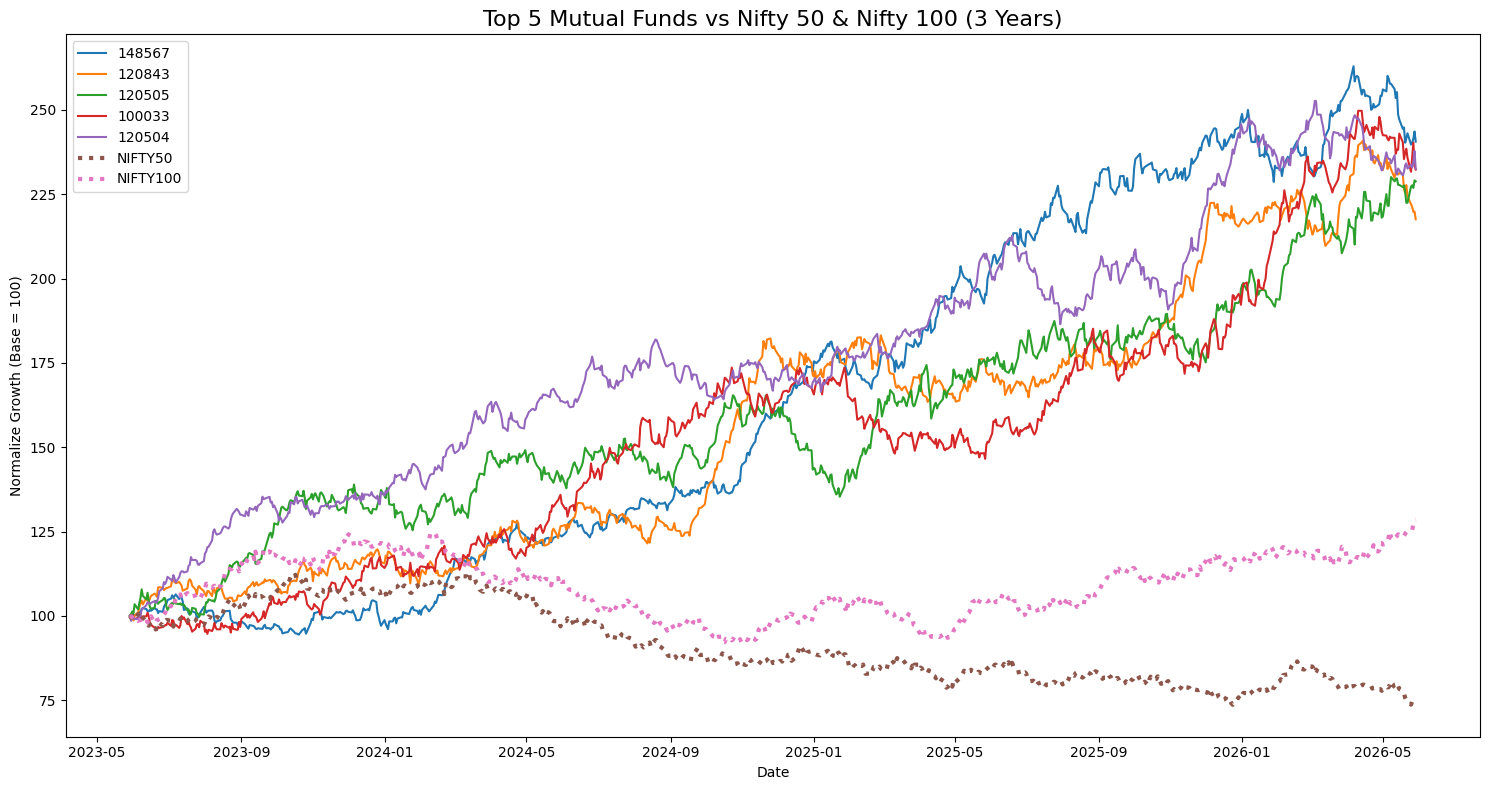

In [138]:
plt.figure(figsize=(15,8))

for code in top5:
    temp = funds[funds['amfi_code'] == code]
    plt.plot(
        temp["date"],
        temp['normalize_nav'],
        label = code
    )
for name in ['NIFTY50', 'NIFTY100'] :
    temp = benchmark[benchmark['index_name'] == name]
    plt.plot(
        temp["date"],
        temp['normalized'],
        linewidth = 3,
        linestyle = ':',
        label = name
    )

plt.title("Top 5 Mutual Funds vs Nifty 50 & Nifty 100 (3 Years)",fontsize=16
)
plt.xlabel("Date")
plt.ylabel("Normalize Growth (Base = 100)")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/benchmark_chart.png", dpi = 300, bbox_inches = "tight")
plt.show()

In [139]:
funds['daily_return']= funds.groupby('amfi_code')['nav'].pct_change()
benchmark['benchmark_return'] = benchmark.groupby('index_name')['close_value'].pct_change()
nifty50 = benchmark[benchmark['index_name'] == "NIFTY50"].reset_index()[['date', 'close_value', 'benchmark_return']]
nifty100 = benchmark[benchmark['index_name'] == "NIFTY100"].reset_index()[['date','index_name', 'close_value', 'benchmark_return']]
funds

,amfi_code,date,nav,normalize_nav,daily_return
2665,100033,2023-05-29,147.2155,100.000000,NaN
2666,100033,2023-05-30,147.2007,99.989947,-0.000101
2667,100033,2023-05-31,147.4640,100.168800,0.001789
2668,100033,2023-06-01,146.5954,99.578781,-0.005890
2669,100033,2023-06-02,145.8015,99.039503,-0.005416
...,...,...,...,...,...
40245,148567,2026-05-25,229.4356,239.742614,-0.013787
40246,148567,2026-05-26,229.9402,240.269883,0.002199
40247,148567,2026-05-27,231.1083,241.490458,0.005080
40248,148567,2026-05-28,233.1530,243.627013,0.008847


In [143]:
def tracking_error(fund, bench_mark):
    merged = pd.merge(fund, bench_mark, on='date', how='inner')
    # print(funds)
    diff = (merged['daily_return'] - merged['benchmark_return'])
    # print(diff)
    return diff.std() * np.sqrt(252)
result = []


for code in top5:
    fund = funds[funds['amfi_code'] == code]
    # print(funds)
    te50 = tracking_error(fund, nifty50)
    te100 = tracking_error(fund, nifty100)
    result.append({
        "amfi_code": code,

        "tracking_error_nifty50":round(te50,4),

        "tracking_error_nifty100":round(te100,4)
    })

tracking = pd.DataFrame(result)
tracking.to_csv("../data/processed/tracking_error.csv", index=False)
tracking

,amfi_code,tracking_error_nifty50,tracking_error_nifty100
0,148567,0.1919,0.1880
1,120843,0.2051,0.2065
2,120505,0.2284,0.2327
3,100033,0.2282,0.2250
4,120504,0.1882,0.1873
